In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(891, 12)


In [9]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [10]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


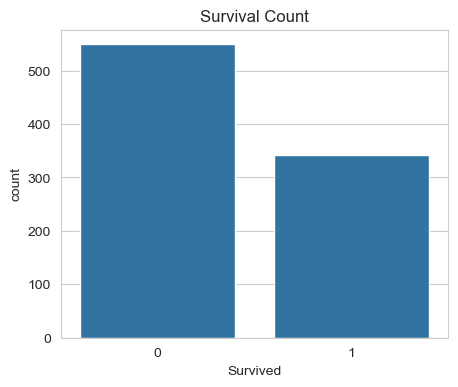

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

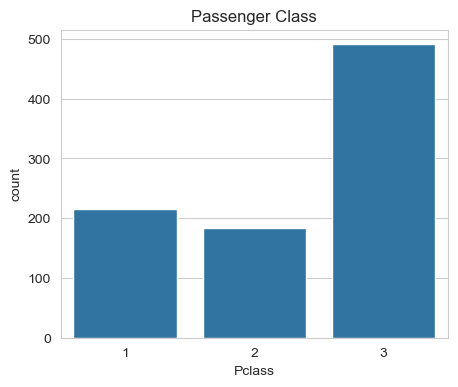

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class")
plt.show()

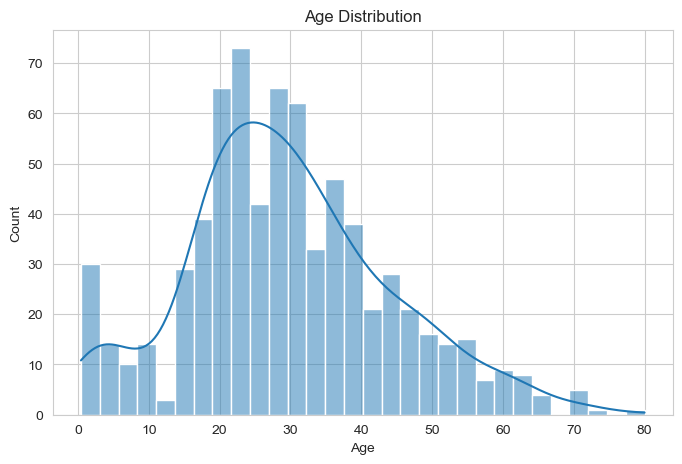

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [18]:
numeric_attributes = [
    "PassengerId",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

print(numeric_attributes)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [19]:
nominal_attributes = [
    "Name",
    "Sex",
    "Ticket",
    "Cabin",
    "Embarked"
]

print(nominal_attributes)

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [20]:
binary_attributes = [
    "Survived",
    "Sex"
]

print("Binary Attributes:")
print(binary_attributes)

Binary Attributes:
['Survived', 'Sex']


In [25]:
# Select two records
obj1 = df.loc[0, ["Sex", "Embarked"]]
obj2 = df.loc[1, ["Sex", "Embarked"]]

print("Passenger 1:")
print(obj1)

print("\nPassenger 2:")
print(obj2)

# Calculate Simple Matching Dissimilarity
mismatches = (obj1 != obj2).sum()
total_attributes = len(obj1)

dissimilarity = mismatches / total_attributes

print("\nNominal Attribute Dissimilarity =", dissimilarity)

Passenger 1:
Sex         male
Embarked       S
Name: 0, dtype: object

Passenger 2:
Sex         female
Embarked         C
Name: 1, dtype: object

Nominal Attribute Dissimilarity = 1.0


In [26]:
from math import sqrt

# Select Age and Fare for first two passengers
x = df.loc[0, ["Age", "Fare"]].astype(float)
y = df.loc[1, ["Age", "Fare"]].astype(float)

print("Passenger 1:")
print(x)

print("\nPassenger 2:")
print(y)

# Euclidean Distance
distance = sqrt(((x - y) ** 2).sum())

print("\nEuclidean Distance =", distance)

Passenger 1:
Age     22.00
Fare     7.25
Name: 0, dtype: float64

Passenger 2:
Age     38.0000
Fare    71.2833
Name: 1, dtype: float64

Euclidean Distance = 66.00199624928021
